## Why NumPy?

- Compact, contiguous arrays of numbers in memory.
- Vectorized operations dispatch to optimized C/BLAS under the hood.
- Expressive APIs for indexing, broadcasting, and linear algebra.
- Foundation for scientific Python (Pandas, SciPy, scikit-learn).

### 1) Review- Creating arrays: 
- Build 1D/2D arrays using `array`, `linspace`, `arange`, and helpers (`zeros`, `ones`, `eye`).

In [ ]:
# Add comments to all code in this Notebook
# You have seen this code before
import numpy as np

# 1D arrays
a = np.array([1, 3, 5, 7], dtype=float)
# 2 x 2 array with all integer elements
b = np.array([[1, 2, 3],
              [4, 5, 6]], dtype= int)
x_lin = np.linspace(0.0, 5.0, 11)     # inclusive ends
x_rng = np.arange(0.0, 5.0, 0.5)      # half-open [start, end)

print('a =\n', a)
print('b =\n', b)
print('lin    =', x_lin)
print('arange =', x_rng)

# 2D helpers
Z = np.zeros((2,3))
O = np.ones((3,2))
I = np.eye(3)
print('zeros:\n', Z)
print('ones:\n',  O)
print('eye:\n',   I)


### 2) Vectorization 
- Example: velocity of a falling object

velocity(1.0) = 9.8
t = [0 1 2 3 4]
v = [ 0.   9.8 19.6 29.4 39.2]


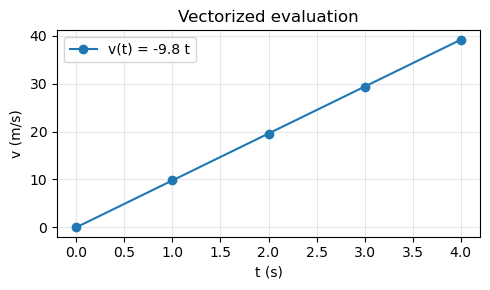

In [2]:
import numpy as np, matplotlib.pyplot as plt # importing .pyplot

def velocity(t): # function -> def with the parameter (t)
    g = 9.8  # m/s^2
    v0 = 0.0
    return g * t + v0

# Scalar works
print('velocity(1.0) =', velocity(1.0))

# Vectorized with NumPy
t = np.array([0,1,2,3,4], dtype=int) # Vactorize t in an array 
# t = np.linspace(0, 4, 20)             # Vactorize t in an array
# if this is used, it's a different way to reach the same plot picture.
v = velocity(t)
print('t =', t)
print('v =', v)

plt.figure(figsize=(5,3)) # how big is the figure shown
plt.plot(t, v, 'o-', label='v(t) = -9.8 t') # scatter and line plot
# plt.xlim(0, 4)
plt.xlabel('t (s)'); plt.ylabel('v (m/s)'); plt.title('Vectorized evaluation') # titles of the plot.
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show() # 


#### Exercise
Calculate and plot the distance of a falling object with the same initial velocity above. 

In [ ]:
# Your code here
import numpy as np, matplotlib.pyplot as plt # importing .pyplot

def velocity(t): # function -> def with the parameter (t)
    g = 9.8  # m/s^2
    v0 = 0.0
    y0 = 100
    return (-1/2)*g*t + v0
# -1/2gt + v0*t + y0

# Scalar works
print('velocity(1.0) =', velocity(1.0))


plt.figure(figsize=(5.2,3.2)) # how big is the figure shown
plt.plot(t, v, 'o-', label='v(t) = -9.8 t') # scatter and line plot
# plt.xlim(0, 4)
plt.xlabel('d (m)'); plt.ylabel('v (m/s)'); plt.title('Vectorized evaluation') # titles of the plot.


### 3) Indexing & slicing (1D and 2D)
- Use basic **indexing & slicing** (including 2D) and perform in-place assignments.

In [13]:
import numpy as np

text = "Happy Halloween!"
print(text[10])
print("Slice:", text[5:7])

A = np.array([[7., 8., 9.],
              [4., 5., 6.]])
print('A=', A, '\nshape =', A.shape)

# Two equivalent ways to index a single element
print('A[1][2] =', A[1][2])
print('A[1,2]  =', A[1,2])

# Row / column slicing
print('Row 0  :', A[0, :])
print('Col 1  :', A[:, 1])

# In-place assignment
A[1, 2] = -A[0, 0]
print('After A[1,2] = -A[0,0]:', A)


o
Slice:  H
A= [[7. 8. 9.]
 [4. 5. 6.]] 
shape = (2, 3)
A[1][2] = 6.0
A[1,2]  = 6.0
Row 0  : [7. 8. 9.]
Col 1  : [8. 5.]
After A[1,2] = -A[0,0]: [[ 7.  8.  9.]
 [ 4.  5. -7.]]


#### Exercise
Make a 3 x 5 array using the function of your choice. 
Print out 1). a particular row, 2). a particular colum, and 3). a particular element

In [17]:
# Your code here
import numpy as np

A = np.array([[3, 4, 5],
              [9, 8, 7],
              [1, 2, 3],
              [10, 11, 12],
              [-6, -7, -8]])
print('A=', A, '\nshape =', A.shape)

print('A[1][2] =', A[4][0])

# Row / column slicing
print('Row 0  :', A[1, :])
print('Col 1  :', A[:, 2])

# In-place assignment
A[1, 2] = -A[0, 0]
print('After A[1,2] = -A[0,0]:', A)


A= [[ 3  4  5]
 [ 9  8  7]
 [ 1  2  3]
 [10 11 12]
 [-6 -7 -8]] 
shape = (5, 3)
A[1][2] = -6
Row 0  : [9 8 7]
Col 1  : [ 5  7  3 12 -8]
After A[1,2] = -A[0,0]: [[ 3  4  5]
 [ 9  8 -3]
 [ 1  2  3]
 [10 11 12]
 [-6 -7 -8]]


### 4) Broadcasting: eliminating loops
- Apply **broadcasting** rules to eliminate loops and generate grids. It works by automatically expanding the smaller array across the larger one so that they have compatible shapes.

Examples below build a coordinate grid without explicit loops and compute a distance field.

[[-2.        ]
 [-1.55555556]
 [-1.11111111]
 [-0.66666667]
 [-0.22222222]
 [ 0.22222222]
 [ 0.66666667]
 [ 1.11111111]
 [ 1.55555556]
 [ 2.        ]]
[[-2.         -1.55555556 -1.11111111 -0.66666667 -0.22222222  0.22222222
   0.66666667  1.11111111  1.55555556  2.        ]]


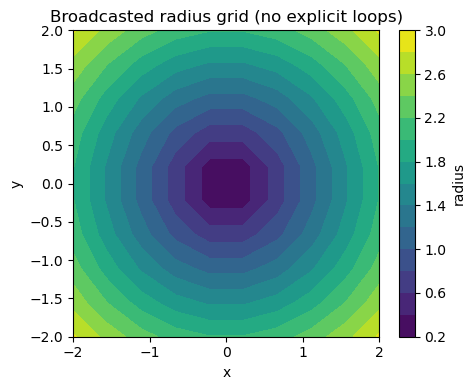

In [20]:
import numpy as np, matplotlib.pyplot as plt

x = np.linspace(-2, 2, num=10, dtype=float)[:, None]   # shape (10,1) column
y = np.linspace(-2, 2, 10, dtype= float)[None, :]   # shape (1,10) row
print(x)
print(y)
X = x + 0*y                             # broadcast to (10,10)
Y = 0*x + y                             # broadcast to (10,10)
R = np.sqrt(X**2 + Y**2)                # element-wise
# print(R)
plt.figure(figsize=(5,4))
plt.contourf(X, Y, R, levels=15, cmap='viridis')
plt.colorbar(label='radius')
plt.gca().set_aspect('equal', 'box')
plt.title('Broadcasted radius grid (no explicit loops)')
plt.xlabel('x'); plt.ylabel('y'); plt.tight_layout(); plt.show()


#### Exercise
Make up a function similar to the example above and plot it. 
Try increase the array sizes and see what heppens. OPTIONAL

[[-5.        ]
 [-4.63157895]
 [-4.26315789]
 [-3.89473684]
 [-3.52631579]
 [-3.15789474]
 [-2.78947368]
 [-2.42105263]
 [-2.05263158]
 [-1.68421053]
 [-1.31578947]
 [-0.94736842]
 [-0.57894737]
 [-0.21052632]
 [ 0.15789474]
 [ 0.52631579]
 [ 0.89473684]
 [ 1.26315789]
 [ 1.63157895]
 [ 2.        ]]
[[-5.         -4.21052632 -3.42105263 -2.63157895 -1.84210526 -1.05263158
  -0.26315789  0.52631579  1.31578947  2.10526316  2.89473684  3.68421053
   4.47368421  5.26315789  6.05263158  6.84210526  7.63157895  8.42105263
   9.21052632 10.        ]]


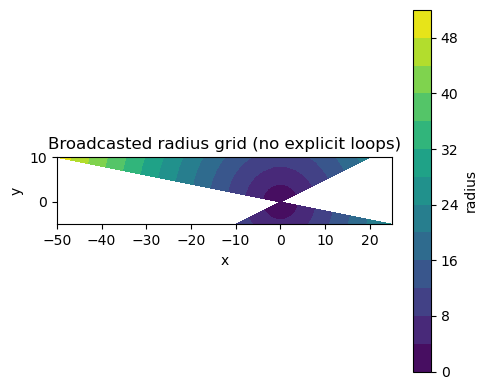

In [31]:
# Your code here. 
import numpy as np, matplotlib.pyplot as plt

x = np.linspace(-5, 2, num=20, dtype=float)[:, None]   # shape (10,1) column
y = np.linspace(-5, 10, 20, dtype= float)[None, :]   # shape (1,10) row
print(x)
print(y)
X = x * y                               # broadcast to (10,10)
Y = 0*x + y                             # broadcast to (10,10)
R = np.sqrt(X**2 + Y**2)                # element-wise
# print(R)
plt.figure(figsize=(5,4))
plt.contourf(X, Y, R, levels=15, cmap='viridis')
plt.colorbar(label='radius')
plt.gca().set_aspect('equal', 'box')
plt.title('Broadcasted radius grid (no explicit loops)')
plt.xlabel('x'); plt.ylabel('y'); plt.tight_layout(); plt.show()


### 5) Dtypes & precision: float32 vs float64
- Choose an appropriate **dtype** and understand precision trade-offs. 

In [ ]:
import numpy as np

# A tiny accumulation example
N = 1_000_000_000 # What does this line of code do?
x = np.ones(N, dtype=np.float32) / N
y = np.ones(N, dtype=np.float64) / N
print('sum float32 ≈', x.sum(), ' error=', abs(x.sum()-1.0))
print('sum float64 ≈', y.sum(), ' error=', abs(y.sum()-1.0))
# Run the code and explain what happens.
# Does it take a longer time (compare to other code) to run? Why or why not?
# before we did not have that much sig figs, but now it's bits, so that's why it's longer. 

sum float32 ≈ 0.9985961  error= 0.0014039278
sum float64 ≈ 1.000000000001517  error= 1.5170087408478139e-12


#### Exercise
Make two arrays using np.array. They have exactly the same elements but different precisions- one of them is float32 and the other one is float 64. Print out the difference of the (third items/1,000,000) in these two arrays. Should it be ZERO?? Why or whynot?

In [ ]:
# Your code here


### 6) Reshape & aggregations (axis)

In [22]:
import numpy as np

B = np.arange(12).reshape(3,4) # What does this line of code do? Can you fix the error?
print('B=', B)
print('sum over rows (axis=1):', B.sum(axis=1)) # What does this line of code do?
print('mean over cols (axis=0):', B.mean(axis=0)) # What does this line of code does?


B= [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
sum over rows (axis=1): [ 6 22 38]
mean over cols (axis=0): [4. 5. 6. 7.]


#### Exercise
Make another array and reshape it. Sum over each row and each colum of this array.

In [ ]:
# Your code here
import numpy as np
A = np.arange(24)
print("A = ", A)
B = A.reshape(4,6) # What does this line of code do? Can you fix the error?
#The error can occur if these two numbers as a product do not equal the value given in np.arange.
print('B=', B)

print('sum over rows (axis=1):', B.sum(axis=1)) # # adds all this axis together, the axis in parenthesses is required and needs to keep the fixed axis accountable.
print('mean over cols (axis=0):', B.mean(axis=0)) # What does this line of code does?
# the line of code takes the numbers mentioned in the array column, adds them together, and divides by the by the amount of elements in the oc

A =  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
B= [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]
 [18 19 20 21 22 23]]
sum over rows (axis=1): [ 15  51  87 123]
mean over cols (axis=0): [ 9. 10. 11. 12. 13. 14.]


### 7) Quick exercises to connect all the things we have learned so far

#### Exercise
Use NumPy array and matplotlib to plot y= x^3 - 2x. 

In [ ]:
# Your code here
import numpy as np



#### Exercise
The dimensions of your arrays are undeclared initially. Use loops or recrusions to plot the function y= x^3 - 2x. You should get the same plot as above.
Hint: Start with a flowchart. You may use append. 

In [ ]:
# Your code here
import numpy as np
import matplotlib.pyplot

x = i ** 3 - 2*i
y = x

for i in range:

plt.plot(x, y, )
plt.title("y = $x^3$ - 2x")
plt.xlabel
plt.ylabel

SyntaxError: expected ':' (2630973146.py, line 8)